## 1.Import Necessary Libraries

In [11]:
pip install LightGBM

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------------------------------ --------- 1.0/1.4 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import AdaBoostClassifier , GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score

import warnings
warnings.filterwarnings("ignore")

## 2.Import Dataset

In [4]:
credit_card_data = pd.read_csv("credit_card_clean.csv")
credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1




### Exploring the variable
* ID : ID of each client

* LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)

* SEX: Gender (1=male, 2=female)

* EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

* MARRIAGE: Marital status (1=married, 2=single, 3=others)

* AGE: Age in years

* PAY_1: Repayment status in September, 2005 (-2 = No consumption, -1 = paid in full, 0 = use of revolving credit (paid minimum only), 1 = payment delay for one month, 2 = payment delay for two months, ... 8 = payment delay for eight months, 9 = payment delay for nine months and above)

* PAY_2: Repayment status in August, 2005 (scale same as above)

* PAY_3: Repayment status in July, 2005 (scale same as above)

* PAY_4: Repayment status in June, 2005 (scale same as above)

* PAY_5: Repayment status in May, 2005 (scale same as above)

* PAY_6: Repayment status in April, 2005 (scale same as above)

* BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

* BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

* BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

* BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

* BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

* BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

* PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

* PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

* PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

* PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

* PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

* PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

#### Target variable
default.payment.next.month: Default payment (1=yes, 0=no)

###### Note: NT is Taiwain Dollars

## 3.Data understanding

In [5]:
credit_card_data.shape

(30000, 25)

In [6]:
credit_card_data.isna().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

In [7]:
credit_card_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX           object
EDUCATION     object
MARRIAGE      object
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

## 4.Data preparation

#### 1. Data cleaning:


 * removing null entries -- in this dataset there is no null entries
 * dropping columns  -- here dropping ID column becz with this ID (name ) not going to predict op 


In [8]:
del credit_card_data["ID"]

In [9]:
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,female,university,married,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,female,university,single,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,female,university,single,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,female,university,married,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,male,university,married,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,male,highschool,married,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,male,highschool,single,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,male,university,single,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,male,highschool,married,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


#### 2.Data Transformation

**How to choose between label encoder and one hot encoder ?**

**Input feature:**
Based on whether it is Parametric or a Non Parametric Model, we will choosing between LE or OHE.

- For Parametric Models[Linear or logistic reg] - better to go with OHE.
- For Non-Parametric Models [DT]- always go with Label Encoding.

**Output feature:**

-Always the output feature, it must be Label Encoder.

#### 2.1 Label encoding

In [20]:
le = LabelEncoder()
credit_card_data["SEX"] = le.fit_transform(credit_card_data["SEX"])  
credit_card_data["EDUCATION"] = le.fit_transform(credit_card_data["EDUCATION"])
credit_card_data["MARRIAGE"] = le.fit_transform(credit_card_data["MARRIAGE"])
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT,EDUCATION\t
0,20000.0,0,3,0,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,3
1,120000.0,0,3,2,26,-1,2,0,0,0,...,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,3
2,90000.0,0,3,2,34,0,0,0,0,0,...,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,3
3,50000.0,0,3,0,37,0,0,0,0,0,...,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,3
4,50000.0,1,3,0,57,-1,0,-1,0,0,...,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,1,0,39,0,0,0,0,0,...,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0,1
29996,150000.0,1,1,2,43,-1,-1,-1,-1,0,...,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0,1
29997,30000.0,1,3,2,37,4,3,2,-1,0,...,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1,3
29998,80000.0,1,1,0,41,1,-1,0,0,0,...,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1,1


Here  0 --> female , 1 --> Male  based on alphabetical 

In [21]:
credit_card_data.dtypes

LIMIT_BAL      float64
SEX              int64
EDUCATION        int64
MARRIAGE         int64
AGE              int64
PAY_1            int64
PAY_2            int64
PAY_3            int64
PAY_4            int64
PAY_5            int64
PAY_6            int64
BILL_AMT1      float64
BILL_AMT2      float64
BILL_AMT3      float64
BILL_AMT4      float64
BILL_AMT5      float64
BILL_AMT6      float64
PAY_AMT1       float64
PAY_AMT2       float64
PAY_AMT3       float64
PAY_AMT4       float64
PAY_AMT5       float64
PAY_AMT6       float64
DEFAULT          int64
EDUCATION\t      int64
dtype: object

Now all the input columns changed to Numerical dtypes

## 5.Model Building

### 5.1 Splitting input and output

In [27]:
X = credit_card_data.drop("DEFAULT",axis=1)
y = credit_card_data["DEFAULT"]


In [29]:
X.shape,y.shape

((30000, 24), (30000,))

### 5.2 Train test split

In [30]:
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.20,random_state=123,shuffle=True,stratify=y)

In [31]:
X_train.shape,y_train.shape


((24000, 24), (24000,))

In [32]:
X_test.shape,y_test.shape

((6000, 24), (6000,))

## 6.Model Training

#### Training Time Analysis 

In [34]:
adaboost_model = AdaBoostClassifier(n_estimators=50)
gb_model  = GradientBoostingClassifier(n_estimators=50)
xgb_model = XGBClassifier(n_estimators=50)
lgb_model = LGBMClassifier(n_estimators=50)

In [37]:
%%time
adaboost_model.fit(X_train,y_train)

CPU times: total: 3.5 s
Wall time: 3.7 s


,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [38]:
%%time
gb_model.fit(X_train,y_train)

CPU times: total: 8.72 s
Wall time: 9.01 s


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [39]:
%%time
xgb_model.fit(X_train,y_train)

CPU times: total: 1.95 s
Wall time: 857 ms


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [41]:
%%time
lgb_model.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.089531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3263
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
CPU times: total: 1.16 s
Wall time: 723 ms


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,50
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### 7.Model Testing  --Predicted op

In [46]:
y_pred_adb = adaboost_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_lgb = lgb_model.predict(X_test)

## 8.Model Evaluation   -- act op , pred op

##### AdaBoost ALgo

In [50]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_adb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_adb),4))
print("Recall Score",round(recall_score(y_test,y_pred_adb)),4)
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_adb))

Accuracy Score: 0.8218
Precision Score: 0.7048
Recall Score 0 4
Confusion Matrix
 [[4487  186]
 [ 883  444]]


##### Gradient boosting

In [51]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_gb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_gb),4))
print("Recall Score",round(recall_score(y_test,y_pred_gb)),4)
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_gb))

Accuracy Score: 0.8233
Precision Score: 0.6949
Recall Score 0 4
Confusion Matrix
 [[4464  209]
 [ 851  476]]


##### XGBM

In [53]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_xgb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_xgb),4))
print("Recall Score",round(recall_score(y_test,y_pred_xgb)),4)
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_xgb))

Accuracy Score: 0.8185
Precision Score: 0.6617
Recall Score 0 4
Confusion Matrix
 [[4424  249]
 [ 840  487]]


##### LGBM

In [54]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_lgb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_lgb),4))
print("Recall Score",round(recall_score(y_test,y_pred_lgb)),4)
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_lgb))

Accuracy Score: 0.8248
Precision Score: 0.696
Recall Score 0 4
Confusion Matrix
 [[4459  214]
 [ 837  490]]


-------------------------------------------------------------------------------------------------

## FEATURE IMPORTANCE

**feature_importances_ shows the relative importance of each feature in a tree-based model. Features with higher values contribute more to the model's decisions.**

**feature_importances_ = Which feature matters more to the model?**

In [61]:
ada_fimp =adaboost_model.feature_importances_
gb_fimp = gb_model.feature_importances_
xgb_fimp = xgb_model.feature_importances_
lgb_fimp = lgb_model.feature_importances_

In [70]:
feature_importance_list = pd.DataFrame(data= {"Features ": X.columns, "Adaboost_features" : ada_fimp,"GB_features" :gb_fimp,"XGB_features" :xgb_fimp
                                             ,"LGB_features" :lgb_fimp})
feature_importance_list

,Features,Adaboost_features,GB_features,XGB_features,LGB_features
0,LIMIT_BAL,0.057269,0.026852,0.020686,114
1,SEX,0.000000,0.001689,0.014167,22
2,EDUCATION,0.000000,0.001058,0.016912,33
3,MARRIAGE,0.017747,0.002796,0.015742,22
4,AGE,0.000000,0.003232,0.015355,93
5,PAY_1,0.513985,0.655314,0.440396,67
6,PAY_2,0.035080,0.093329,0.090265,32
7,PAY_3,0.052493,0.041462,0.056189,41
8,PAY_4,0.004686,0.016298,0.040710,23
9,PAY_5,0.017710,0.013692,0.035140,26


### Display Top 10 features

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

In [93]:
adaboost_top_features = feature_importance_list.sort_values(by = "Adaboost_features",ascending = False)
top_10_adaboost_features = adaboost_top_features.head(10)
top_10_adaboost_features

,Features,Adaboost_features,GB_features,XGB_features,LGB_features
5,PAY_1,0.513985,0.655314,0.440396,67
17,PAY_AMT1,0.087824,0.021428,0.019545,78
18,PAY_AMT2,0.064727,0.017985,0.020704,97
0,LIMIT_BAL,0.057269,0.026852,0.020686,114
7,PAY_3,0.052493,0.041462,0.056189,41
10,PAY_6,0.042327,0.018587,0.034795,42
19,PAY_AMT3,0.037968,0.020130,0.023774,86
6,PAY_2,0.035080,0.093329,0.090265,32
20,PAY_AMT4,0.019563,0.010408,0.018796,76
15,BILL_AMT5,0.018466,0.002390,0.015598,69


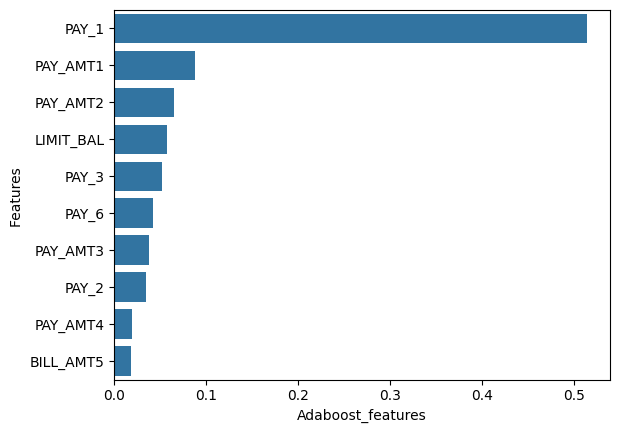

In [94]:
sns.barplot(
    data=top_10_adaboost_features,
    y="Features ",
    x="Adaboost_features"
)
plt.show()

Like this do for GB , XGB LGB